In [ ]:
from transformers import pipeline, ElectraTokenizer, ElectraForSequenceClassification

#Text Classification
classifier = pipeline("text-classification", model="google/electra-base-discriminator", tokenizer="google/electra-base-discriminator")

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# pickin up one review

import pandas as pd
import numpy as np

csv_path = '/content/drive/MyDrive/combined_df_exploded_1.csv'
combined_df_exploded = pd.read_csv(csv_path)

# Preview the data
combined_df_exploded.head()


,review_date,movie_id,user_id,is_spoiler,review_text,rating_x,review_summary,plot_summary,duration,genre,rating_y,release_date,plot_synopsis
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
1,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,Chronicles the experiences of a formerly succe...,2h 22min,Drama,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
2,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
3,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,Chronicles the experiences of a formerly succe...,2h 22min,Drama,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
4,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."


In [ ]:
test_review = combined_df_exploded['review_text'][0]
classifier(test_review, truncation=True)

[{'label': 'LABEL_1', 'score': 0.5138670802116394}]

Loading the Model

In [ ]:
!pip install transformers
!pip install datasets
!pip install evaluate
# !pip install transformers torch

In [ ]:
import torch
print(torch.__version__)

2.6.0+cu124


In [ ]:
from transformers import ElectraTokenizer, ElectraForSequenceClassification

model_name = "google/electra-base-discriminator"

electra_tokenizer = ElectraTokenizer.from_pretrained(model_name)
electra_model = ElectraForSequenceClassification.from_pretrained(model_name, num_labels=2, hidden_dropout_prob=0.05) #hidden dropout because of imbalance in dataset


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
print(electra_tokenizer)

ElectraTokenizer(name_or_path='google/electra-base-discriminator', vocab_size=30522, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [ ]:
print(electra_model)

ElectraForSequenceClassification(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.05, inplace=False)
    )
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): 

In [ ]:
input_str = "Spoiler alert!"

input_tokens = electra_tokenizer.tokenize(input_str)
print(f"Tokens of the input sequence: {input_tokens}")

input_ids = electra_tokenizer.convert_tokens_to_ids(input_tokens)
print(f"IDs assigned to the intput sequence: {input_ids}")

decoded = electra_tokenizer.decode(input_ids)
print(decoded)

model_inputs = electra_tokenizer("Spoiler alert!", padding=True, truncation=True, return_tensors="pt")
print(model_inputs)

Tokens of the input sequence: ['spoil', '##er', 'alert', '!']
IDs assigned to the intput sequence: [27594, 2121, 9499, 999]
spoiler alert!
{'input_ids': tensor([[  101, 27594,  2121,  9499,   999,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}


Loading Metrics

In [ ]:
!pip install transformers
!pip install datasets
!pip install evaluate
import evaluate

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
f1_metric = evaluate.load("f1")
recall_metric = evaluate.load('recall')

matthews_metric = evaluate.load("matthews_correlation")

In [ ]:
print(accuracy_metric.description)


Accuracy is the proportion of correct predictions among the total number of cases processed. It can be computed with:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
 Where:
TP: True positive
TN: True negative
FP: False positive
FN: False negative



In [ ]:
print(precision_metric.description)


Precision is the fraction of correctly labeled positive examples out of all of the examples that were labeled as positive. It is computed via the equation:
Precision = TP / (TP + FP)
where TP is the True positives (i.e. the examples correctly labeled as positive) and FP is the False positive examples (i.e. the examples incorrectly labeled as positive).



In [ ]:
print(f1_metric.description)


The F1 score is the harmonic mean of the precision and recall. It can be computed with the equation:
F1 = 2 * (precision * recall) / (precision + recall)



In [ ]:
print(recall_metric.description)


Recall is the fraction of the positive examples that were correctly labeled by the model as positive. It can be computed with the equation:
Recall = TP / (TP + FN)
Where TP is the true positives and FN is the false negatives.



In [ ]:
print(matthews_metric.description)


Compute the Matthews correlation coefficient (MCC)

The Matthews correlation coefficient is used in machine learning as a
measure of the quality of binary and multiclass classifications. It takes
into account true and false positives and negatives and is generally
regarded as a balanced measure which can be used even if the classes are of
very different sizes. The MCC is in essence a correlation coefficient value
between -1 and +1. A coefficient of +1 represents a perfect prediction, 0
an average random prediction and -1 an inverse prediction.  The statistic
is also known as the phi coefficient. [source: Wikipedia]



Loading the Dataset for the Model

In [ ]:
from datasets import load_dataset, DatasetDict, Dataset
from transformers import DataCollatorWithPadding

In [ ]:
#for training we need to remove unnecessary columns from the dataset
combined_df_exploded_cleaned = combined_df_exploded[['review_text', 'is_spoiler']]

combined_df_exploded_cleaned.head()

,review_text,is_spoiler
0,"In its Oscar year, Shawshank Redemption (writt...",True
1,"In its Oscar year, Shawshank Redemption (writt...",True
2,The Shawshank Redemption is without a doubt on...,True
3,The Shawshank Redemption is without a doubt on...,True
4,I believe that this film is the best story eve...,True


In [ ]:
combined_df_exploded_cleaned['is_spoiler'].value_counts()

,count
is_spoiler,
False,152888
True,52416


In [ ]:
#rename columns into 'text' and 'label'
combined_df_exploded_cleaned = combined_df_exploded_cleaned.rename(columns={'review_text': 'text', 'is_spoiler': 'label'})

#change True and False to 1 and 0
combined_df_exploded_cleaned['label'] = combined_df_exploded_cleaned['label'].astype(int)

combined_df_exploded_cleaned.head()

,text,label
0,"In its Oscar year, Shawshank Redemption (writt...",1
1,"In its Oscar year, Shawshank Redemption (writt...",1
2,The Shawshank Redemption is without a doubt on...,1
3,The Shawshank Redemption is without a doubt on...,1
4,I believe that this film is the best story eve...,1


Splitting the Dataset

In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict

df = combined_df_exploded_cleaned.copy()

def truncate_text(text):
    return " ".join(text.split()[:100])
df["text"] = df["text"].apply(truncate_text)

# 64 for each class
label_0 = df[df["label"] == 0].sample(n=64, random_state=42)
label_1 = df[df["label"] == 1].sample(n=64, random_state=42)
train_df = pd.concat([label_0, label_1]).sample(frac=1, random_state=42)

# 16 for val and test
label_0_rest = df[df["label"] == 0].drop(label_0.index)
label_1_rest = df[df["label"] == 1].drop(label_1.index)
val_df = pd.concat([
    label_0_rest.sample(n=32, random_state=43),
    label_1_rest.sample(n=32, random_state=43)
]).sample(frac=1, random_state=43)
test_df = pd.concat([
    label_0_rest.drop(val_df[val_df["label"] == 0].index).sample(n=32, random_state=44),
    label_1_rest.drop(val_df[val_df["label"] == 1].index).sample(n=32, random_state=44)
]).sample(frac=1, random_state=44)

small_spoiler_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "val": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})


In [ ]:
from transformers import AutoTokenizer

electra_tokenizer = AutoTokenizer.from_pretrained("google/electra-base-discriminator")

def tokenize_function(examples):
    return electra_tokenizer(examples["text"], padding=True, truncation=True)

In [ ]:
small_tokenized_dataset = small_spoiler_dataset.map(tokenize_function, batched=True, batch_size=16)
data_collator = DataCollatorWithPadding(tokenizer=electra_tokenizer)

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

In [ ]:
small_tokenized_dataset['train']['text'][0]

'I would have given this the 1 it deserves but since it\'s not based on an actual event I cut them some slack.I\'m so glad that Einstein figured out the principals of relativity. Most of the people I meet still think the world revolves around them. Then Einstein played the "what if" game with Physics. What if you could travel near the speed of light and take a trip, blah, blah, blah. You can\'t. They can\'t. Here\'s where the 8.8 rating comes from. People want to believe almost anything that is impossible. This movie is garbage.I\'m not humorless. Time travel'

In [ ]:
small_tokenized_dataset['train'][0]

{'text': 'I would have given this the 1 it deserves but since it\'s not based on an actual event I cut them some slack.I\'m so glad that Einstein figured out the principals of relativity. Most of the people I meet still think the world revolves around them. Then Einstein played the "what if" game with Physics. What if you could travel near the speed of light and take a trip, blah, blah, blah. You can\'t. They can\'t. Here\'s where the 8.8 rating comes from. People want to believe almost anything that is impossible. This movie is garbage.I\'m not humorless. Time travel',
 'label': 0,
 'input_ids': [101,
  1045,
  2052,
  2031,
  2445,
  2023,
  1996,
  1015,
  2009,
  17210,
  2021,
  2144,
  2009,
  1005,
  1055,
  2025,
  2241,
  2006,
  2019,
  5025,
  2724,
  1045,
  3013,
  2068,
  2070,
  19840,
  1012,
  1045,
  1005,
  1049,
  2061,
  5580,
  2008,
  15313,
  6618,
  2041,
  1996,
  27928,
  1997,
  20805,
  1012,
  2087,
  1997,
  1996,
  2111,
  1045,
  3113,
  2145,
  2228,
 

One Shot Training with Pipeline from Hugging Face

Just Classifier

In [ ]:
# pickin up one review
test_review = small_tokenized_dataset['train']['text'][0]
print(test_review)

I would have given this the 1 it deserves but since it's not based on an actual event I cut them some slack.I'm so glad that Einstein figured out the principals of relativity. Most of the people I meet still think the world revolves around them. Then Einstein played the "what if" game with Physics. What if you could travel near the speed of light and take a trip, blah, blah, blah. You can't. They can't. Here's where the 8.8 rating comes from. People want to believe almost anything that is impossible. This movie is garbage.I'm not humorless. Time travel


In [ ]:
test_answer = small_tokenized_dataset['train']['label'][0]
print(test_answer)

0


In [ ]:
from transformers import pipeline

# Text Classification:
classifier = pipeline("text-classification")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


In [ ]:
outputs = classifier(test_review)

print(outputs)

[{'label': 'NEGATIVE', 'score': 0.9985334873199463}]


With Model

In [ ]:
from transformers import AutoModelForSequenceClassification

In [ ]:
model_id = "google/electra-base-discriminator"
electra_model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)
electra_tokenizer = AutoTokenizer.from_pretrained(model_id)
classifier = pipeline("text-classification", model=electra_model, tokenizer=electra_tokenizer)


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


In [ ]:
preds = classifier(test_review, return_all_scores=True)

print(preds)

[[{'label': 'LABEL_0', 'score': 0.5071001648902893}, {'label': 'LABEL_1', 'score': 0.4928998053073883}]]


/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


One Shot Training with Model

In [ ]:
# Text zum Tokenizer
model_inputs = electra_tokenizer(test_review, return_tensors="pt")

# Verschiebe die Eingabetensoren auf die gleiche Device wie das Modell
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
electra_model.to(device)
model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

# Modell ausführen
with torch.no_grad():
    model_outputs = electra_model(**model_inputs)

print(model_outputs)

print(f'model outputs:{model_inputs}')

print(f'model outputs: {model_outputs}')

SequenceClassifierOutput(loss=None, logits=tensor([[-0.0258, -0.0542]], device='cuda:0'), hidden_states=None, attentions=None)
model outputs:{'input_ids': tensor([[  101,  1045,  2052,  2031,  2445,  2023,  1996,  1015,  2009, 17210,
          2021,  2144,  2009,  1005,  1055,  2025,  2241,  2006,  2019,  5025,
          2724,  1045,  3013,  2068,  2070, 19840,  1012,  1045,  1005,  1049,
          2061,  5580,  2008, 15313,  6618,  2041,  1996, 27928,  1997, 20805,
          1012,  2087,  1997,  1996,  2111,  1045,  3113,  2145,  2228,  1996,
          2088, 19223,  2105,  2068,  1012,  2059, 15313,  2209,  1996,  1000,
          2054,  2065,  1000,  2208,  2007,  5584,  1012,  2054,  2065,  2017,
          2071,  3604,  2379,  1996,  3177,  1997,  2422,  1998,  2202,  1037,
          4440,  1010, 27984,  1010, 27984,  1010, 27984,  1012,  2017,  2064,
          1005,  1056,  1012,  2027,  2064,  1005,  1056,  1012,  2182,  1005,
          1055,  2073,  1996,  1022,  1012,  1022,  579

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

# 1. Load sample from dataset
sample = small_tokenized_dataset['test'][0]  # or ['val'][0]

# 2. Extract label (must be tensor)
true_label = torch.tensor([sample['label']])

# 3. Prepare model input
model_inputs = {
    'input_ids': torch.tensor([sample['input_ids']]),
    'attention_mask': torch.tensor([sample['attention_mask']])
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
electra_model.to(device)
model_inputs = {k: v.to(device) for k, v in model_inputs.items()}
true_label = true_label.to(device)

# 4. Run model (no gradient needed)
with torch.no_grad():
    outputs = electra_model(**model_inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1)

In [ ]:
# 5. Compute metrics
accuracy_score = accuracy_metric.compute(predictions=predictions, references=true_label)
precision_score = precision_metric.compute(predictions=predictions, references=true_label)
recall_score = recall_metric.compute(predictions=predictions, references=true_label)
f1_score = f1_metric.compute(predictions=predictions, references=true_label)
matthews_score = matthews_metric.compute(predictions=predictions, references=true_label)

print(f"True label: {true_label.item()} | Predicted: {predictions.item()}")
print(f"Accuracy: {accuracy_score}")
print(f"Precision: {precision_score}")
print(f"Recall: {recall_score}")
print(f"F1: {f1_score}")
print(f"Matthews Corellation: {matthews_score}")

True label: 1 | Predicted: 0
Accuracy: {'accuracy': 0.0}
Precision: {'precision': 0.0}
Recall: {'recall': 0.0}
F1: {'f1': 0.0}
Matthews Corellation: {'matthews_correlation': 0.0}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# we add weights to improve the results
labels = small_tokenized_dataset['train']['label']
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([1., 1.])


In [ ]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        global class_weights
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
import numpy as np
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification

electra_model = AutoModelForSequenceClassification.from_pretrained("google/electra-base-discriminator", num_labels=2, hidden_dropout_prob=0.02, attention_probs_dropout_prob=0.05,  # Auch reduziert
    classifier_dropout=0.05  # Falls verfügbar
)

arguments = TrainingArguments(
    output_dir="/content/drive/MyDrive/sample_cl_trainer",
    per_device_train_batch_size=8, #16
    per_device_eval_batch_size=8, #16
    logging_steps=4,
    num_train_epochs=5,
    eval_strategy="epoch", # run validation at the end of each epoch
    save_strategy="epoch",
    learning_rate=5e-6, #best as of: 1e-5 #2e-5
    weight_decay=0.001,#0.01
    load_best_model_at_end=True,
    gradient_accumulation_steps=4,
    label_smoothing_factor=0.1,
    report_to='none',
    seed=42 #224
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
        "matthews_correlation": matthews_metric.compute(predictions=predictions, references=labels)["matthews_correlation"]}


trainer = WeightedTrainer(
    model=electra_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'],
    tokenizer=electra_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-155-f0b98faa2bb7>:37: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Matthews Correlation
1,0.700100,0.689577,0.593750,0.555556,0.937500,0.697674,0.258199
2,0.689300,0.688294,0.609375,0.568627,0.906250,0.698795,0.271857
3,0.690300,0.687206,0.625000,0.580000,0.906250,0.707317,0.302372
4,0.687500,0.686545,0.625000,0.583333,0.875000,0.700000,0.288675
5,0.679400,0.686307,0.625000,0.583333,0.875000,0.700000,0.288675


TrainOutput(global_step=20, training_loss=0.6893264651298523, metrics={'train_runtime': 57.2354, 'train_samples_per_second': 11.182, 'train_steps_per_second': 0.349, 'total_flos': 55261543846080.0, 'train_loss': 0.6893264651298523, 'epoch': 5.0})

In [ ]:
# to see if the models predicts always 0

from collections import Counter
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = preds.argmax(axis=1)
print(Counter(pred_labels))  # Count predicted classes

true_labels = small_tokenized_dataset['val']['label']
print(Counter(true_labels))  # Count actual classes

Counter({np.int64(1): 48, np.int64(0): 16})
Counter({1: 32, 0: 32})


In [ ]:
print(trainer.state.best_model_checkpoint)

/content/drive/MyDrive/sample_cl_trainer/checkpoint-20


In [ ]:
from collections import Counter
import numpy as np

# Get predictions
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = np.argmax(preds, axis=1)

# Count how many of each label are predicted
print("Predicted label counts:", Counter(pred_labels))

# Compare with ground truth
true_labels = small_tokenized_dataset['val']['label']
print("True label counts:", Counter(true_labels))

Predicted label counts: Counter({np.int64(1): 48, np.int64(0): 16})
True label counts: Counter({1: 32, 0: 32})


<Axes: >

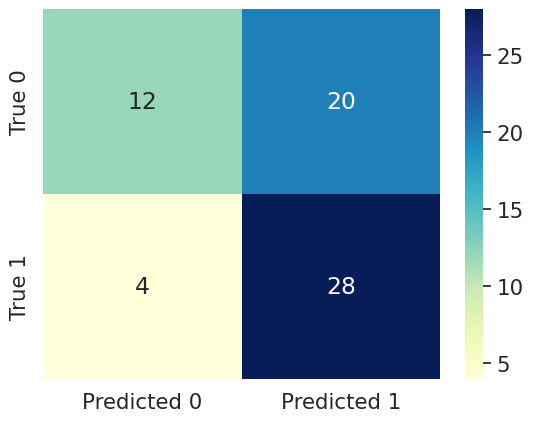

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sn

conf_mat = metrics.confusion_matrix(true_labels, pred_labels)
df_cm = pd.DataFrame(conf_mat, ["True 0","True 1"], ["Predicted 0","Predicted 1"])

sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='d', cmap="YlGnBu")

Testing

In [ ]:
fine_tuned_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/sample_cl_trainer/checkpoint-20")

One Review

In [ ]:
model_inputs = electra_tokenizer(test_review, return_tensors="pt")
prediction = torch.argmax(fine_tuned_model(**model_inputs).logits)

print(["Non-Spoiler", "Spoiler"][prediction])

Spoiler


Test Set

In [ ]:
trainer = Trainer(
    model=fine_tuned_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['test'], #change to test for final step
    tokenizer=electra_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

<ipython-input-165-24d11187b32c>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.evaluate(eval_dataset=small_tokenized_dataset['test'])

{'eval_loss': 0.6982166767120361,
 'eval_model_preparation_time': 0.0031,
 'eval_accuracy': 0.484375,
 'eval_precision': 0.4857142857142857,
 'eval_recall': 0.53125,
 'eval_f1': 0.5074626865671642,
 'eval_matthews_correlation': -0.03138824102871723,
 'eval_runtime': 0.2823,
 'eval_samples_per_second': 226.681,
 'eval_steps_per_second': 28.335}